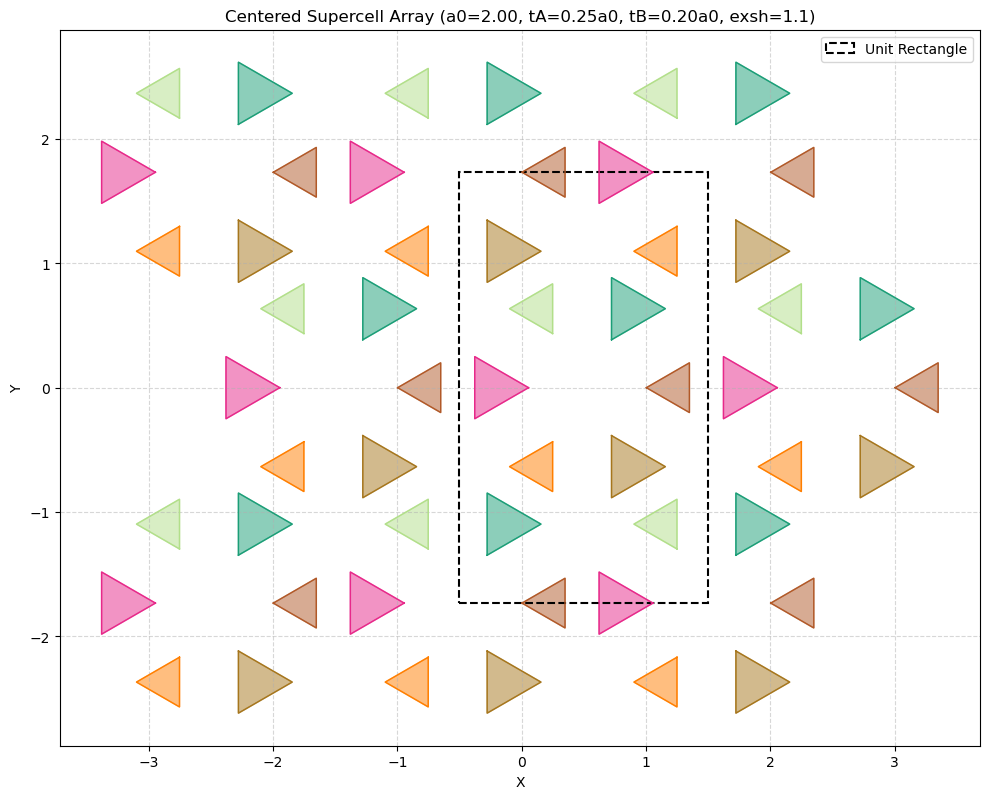

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_unitcell(ax, offset=np.array([[0], [0]]), a0=2.0, tA_ratio=0.25, tB_ratio=0.20, exsh=1.1):
    """
    Function to draw a single unit cell containing small triangles A and B.
    """
    # Calculate side length of large triangle back from a0 = sqrt(3) * side_large
    side_large = a0 / np.sqrt(3)
    tA = tA_ratio * a0
    tB = tB_ratio * a0

    height_large = side_large * np.sqrt(3) / 2  # Height = a0 / 2
    height_smallA = tA * np.sqrt(3) / 2
    height_smallB = tB * np.sqrt(3) / 2

    # Centroid position relative to origin (top vertex at 0,0)
    centroid_y = - (2 / 3) * height_large

    # Helper function to compute coordinates for small triangles
    def get_small_coords(side, height):
        x = np.array([0, -side / 2, side / 2, 0])
        y = np.array([
            centroid_y * exsh + (2 / 3) * height,
            centroid_y * exsh - (1 / 3) * height,
            centroid_y * exsh - (1 / 3) * height,
            centroid_y * exsh + (2 / 3) * height
        ])
        return np.vstack((x, y))

    coords_smallA = get_small_coords(tA, height_smallA)
    coords_smallB = get_small_coords(tB, height_smallB)

    # Color palettes for small triangles
    colors_smallA = plt.cm.Dark2(np.linspace(0, 1, 6))
    colors_smallB = plt.cm.Paired(np.linspace(0, 1, 6))

    angles = [60, 120, 180, 240, 300, 360]

    # Global rotation of 90 degrees
    global_shift_rad = np.radians(90)
    R_global = np.array([
        [np.cos(global_shift_rad), -np.sin(global_shift_rad)],
        [np.sin(global_shift_rad),  np.cos(global_shift_rad)]
    ])

    for i, angle_deg in enumerate(angles):
        angle_rad = np.radians(angle_deg)
        R = np.array([
            [np.cos(angle_rad), -np.sin(angle_rad)],
            [np.sin(angle_rad),  np.cos(angle_rad)]
        ])
        R_total = R_global @ R

        # Plot small triangles A/B
        if angle_deg in [60, 180, 300]:
            rot_small = R_total @ coords_smallA + offset
            c = colors_smallA[i]
        else:
            rot_small = R_total @ coords_smallB + offset
            c = colors_smallB[i]

        ax.plot(rot_small[0], rot_small[1], color=c, linewidth=1.0)
        ax.fill(rot_small[0], rot_small[1], color=c, alpha=0.5)

# --- Supercell Plotting ---
# Parameter setup
a0 = 2.0           # Lattice constant
tA_ratio = 0.25    # tA = 0.25 * a0
tB_ratio = 0.20    # tB = 0.20 * a0
exsh = 1.1

# Derived side_large from a0
side_large = a0 / np.sqrt(3)

# Define lattice vectors (a1, a2)
a1x, a1y = a0, 0.0
a2x, a2y = a0 / 2.0, 1.5 * side_large  # Height component: (sqrt(3)/2) * a0

Nx, Ny = 3, 3

# Calculate supercell center to shift origin to (0,0)
offsets_x = []
offsets_y = []

for m in range(Ny):
    shift_factor = -(m // 2)
    for n in range(Nx):
        tx = (n + shift_factor) * a1x + m * a2x
        ty = n * a1y + m * a2y
        offsets_x.append(tx)
        offsets_y.append(ty)

# Compute center of the lattice grid
center_x = (min(offsets_x) + max(offsets_x)) / 2.0
center_y = (min(offsets_y) + max(offsets_y)) / 2.0

fig, ax = plt.subplots(figsize=(10, 10))

# Shifted unit cell centers array
unitcell_centers = []

# Plot each unit cell shifted by center offset
for tx, ty in zip(offsets_x, offsets_y):
    ux = tx - center_x
    uy = ty - center_y
    unitcell_centers.append((ux, uy))
    
    offset = np.array([[ux], [uy]])
    draw_unitcell(ax, offset=offset, a0=a0, tA_ratio=tA_ratio, tB_ratio=tB_ratio, exsh=exsh)

# Find unitcell center closest to origin (0, 0)
unitcell_centers = np.array(unitcell_centers)
distances = np.hypot(unitcell_centers[:, 0], unitcell_centers[:, 1])
closest_idx = np.argmin(distances)
closest_center_x, closest_center_y = unitcell_centers[closest_idx]

# Rectangle dimensions
rect_width = a0
rect_height = np.sqrt(3) * a0

# Draw dashed rectangle centered at the closest unitcell's center
rect = patches.Rectangle(
    (closest_center_x - rect_width / 2.0, closest_center_y - rect_height / 2.0),
    rect_width,
    rect_height,
    linewidth=1.5,
    linestyle='--',
    edgecolor='black',
    facecolor='none',
    label='Unit Rectangle'
)
ax.add_patch(rect)

# Plot formatting
ax.set_aspect('equal', adjustable='box')
ax.set_title(f'Centered Supercell Array (a0={a0:.2f}, tA={tA_ratio:.2f}a0, tB={tB_ratio:.2f}a0, exsh={exsh})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

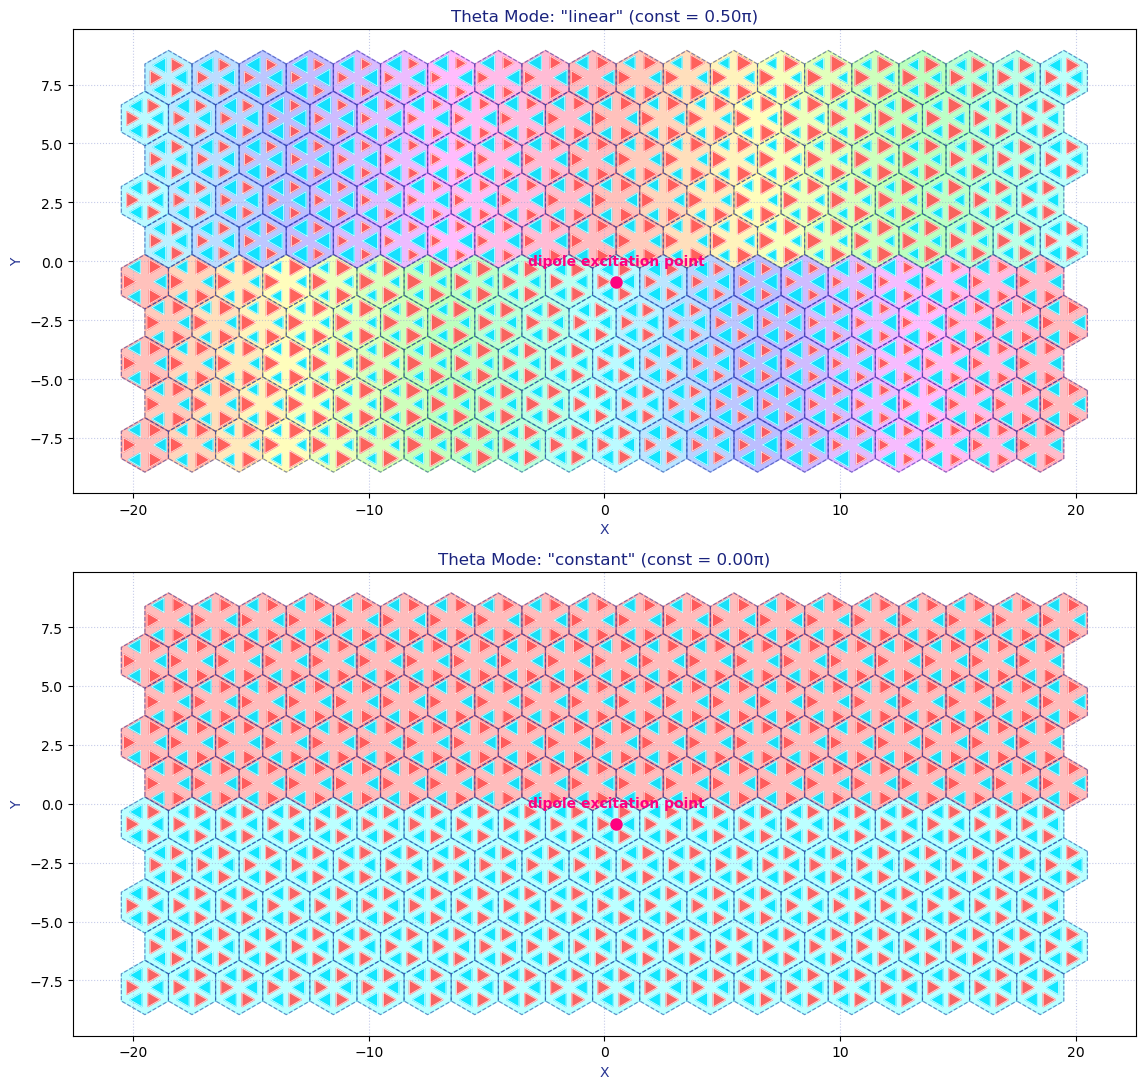

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ==========================================
# 1. ユーザー定義パラメータ（まとめて設定）
# ==========================================
CONFIG = {
    # --- Grid Parameters ---
    'Nx': 20,                # X方向のユニットセル数
    'Ny': 10,                 # Y方向のユニットセル数
    'a0': 2.0,               # 格子定数

    # --- Structural Parameters ---
    'spatial_period_factor': 20.0, # 空間周期の係数 (spatial_period = factor * a0)
    'exsh_amplitude': 0.1,    # exsh = 1.0 + amplitude * sin(theta)
    't0_ratio': 0.3,         # t0 = ratio * a0
    'delta_t_ratio': 0.2,    # delta_t = ratio * t0

    # --- Color & Theme Settings ---
    'color_smallA': '#FF5252',  # 小三角形A: 鮮やかなコーラルピンク
    'color_smallB': '#00E5FF',  # 小三角形B: 鮮やかなシアン
    'hex_saturation': 0.75,     # 六角形の背景色の彩度 (0.0: グレー ~ 1.0: 鮮やか)
    'hex_value': 1.0,          # 六角形の背景色の明度 (0.0: 黒 ~ 1.0: 明るい)
    'hex_alpha': 0.35,         # 六角形背景の透過度
    'border_color': '#303F9F',  # 境界線（破線）の色
    'dipole_color': '#FF007F',  # 励振点の色
}


# ==========================================
# 2. 描画関数定義
# ==========================================
def draw_unitcell(ax, offset=np.array([[0], [0]]), theta=0.0, cfg=CONFIG):
    """
    1つのユニットセルを描画する関数
    """
    a0 = cfg['a0']
    
    # パラメータ計算
    exsh = 1.0 + cfg['exsh_amplitude'] * np.cos(theta)
    t0 = cfg['t0_ratio'] * a0
    delta_t = cfg['delta_t_ratio'] * t0
    
    tA = t0 + delta_t * np.sin(theta)
    tB = t0 - delta_t * np.sin(theta)

    side_large = a0 / np.sqrt(3)
    height_large = side_large * np.sqrt(3) / 2
    height_smallA = tA * np.sqrt(3) / 2
    height_smallB = tB * np.sqrt(3) / 2

    centroid_y = - (2 / 3) * height_large

    # 大三角形の座標
    x_large = np.array([0, -side_large / 2, side_large / 2, 0])
    y_large = np.array([0, -height_large, -height_large, 0])
    coords_large = np.vstack((x_large, y_large))

    # 小三角形の座標計算ヘルパー
    def get_small_coords(side, height):
        x = np.array([0, -side / 2, side / 2, 0])
        y = np.array([
            centroid_y * exsh + (2 / 3) * height,
            centroid_y * exsh - (1 / 3) * height,
            centroid_y * exsh - (1 / 3) * height,
            centroid_y * exsh + (2 / 3) * height
        ])
        return np.vstack((x, y))

    coords_smallA = get_small_coords(tA, height_smallA)
    coords_smallB = get_small_coords(tB, height_smallB)

    angles = [60, 120, 180, 240, 300, 360]
    global_shift_rad = np.radians(90)
    R_global = np.array([
        [np.cos(global_shift_rad), -np.sin(global_shift_rad)],
        [np.sin(global_shift_rad),  np.cos(global_shift_rad)]
    ])

    hexagon_vertices = []

    for angle_deg in angles:
        angle_rad = np.radians(angle_deg)
        R = np.array([
            [np.cos(angle_rad), -np.sin(angle_rad)],
            [np.sin(angle_rad),  np.cos(angle_rad)]
        ])
        R_total = R_global @ R

        rot_large = R_total @ coords_large + offset
        hexagon_vertices.append(rot_large[:, 1])

        if angle_deg in [60, 180, 300]:
            rot_small = R_total @ coords_smallA + offset
            c = cfg['color_smallA']
        else:
            rot_small = R_total @ coords_smallB + offset
            c = cfg['color_smallB']

        ax.fill(rot_small[0], rot_small[1], color=c, alpha=0.9, zorder=2)
        ax.plot(rot_small[0], rot_small[1], color='white', linewidth=0.6, alpha=0.8, zorder=3)

    # --- 六角形の周期色塗りつぶし (0 = 2pi 対応) ---
    hue = (theta % (2.0 * np.pi)) / (2.0 * np.pi)
    rgb = mcolors.hsv_to_rgb([hue, cfg['hex_saturation'], cfg['hex_value']])

    hexagon_vertices.append(hexagon_vertices[0])
    hex_coords = np.array(hexagon_vertices).T

    ax.fill(hex_coords[0], hex_coords[1], color=rgb, alpha=cfg['hex_alpha'], zorder=0)
    ax.plot(hex_coords[0], hex_coords[1], color=cfg['border_color'], linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)


def plot_supercell(ax, mode="linear", const_theta=np.pi/2, cfg=CONFIG):
    """
    スーパーセル配列を描画する関数
    """
    Nx, Ny, a0 = cfg['Nx'], cfg['Ny'], cfg['a0']
    side_large = a0 / np.sqrt(3)

    a1x, a1y = a0, 0.0
    a2x, a2y = a0 / 2.0, 1.5 * side_large

    offsets_x = []
    offsets_y = []

    for m in range(Ny):
        shift_factor = -(m // 2)
        for n in range(Nx):
            tx = (n + shift_factor) * a1x + m * a2x
            ty = n * a1y + m * a2y
            offsets_x.append(tx)
            offsets_y.append(ty)

    center_x = (min(offsets_x) + max(offsets_x)) / 2.0
    center_y = (min(offsets_y) + max(offsets_y)) / 2.0

    unitcell_centers = []

    for tx, ty in zip(offsets_x, offsets_y):
        ux = tx - center_x
        uy = ty - center_y
        offset = np.array([[ux], [uy]])
        unitcell_centers.append((ux, uy))
        
        # モードに応じた theta の計算
        if mode == "linear":
            spatial_period = cfg['spatial_period_factor'] * a0
            theta = (2.0 * np.pi / spatial_period) * ux
        elif mode == "constant":
            theta = const_theta
        else:
            raise ValueError("mode must be 'linear' or 'constant'")

        if uy < 0:
            theta += np.pi
        
        draw_unitcell(ax, offset=offset, theta=theta, cfg=cfg)

    # 原点に最も近いセル（Dipole Excitation Point）の特定
    distances = [np.hypot(cx, cy) for cx, cy in unitcell_centers]
    nearest_idx = np.argmin(distances)
    dipole_x, dipole_y = unitcell_centers[nearest_idx]

    # ポインター描画
    ax.plot(dipole_x, dipole_y, marker='o', color=cfg['dipole_color'], markersize=8, zorder=5)
    ax.text(
        dipole_x, dipole_y + 0.6, 
        'dipole excitation point', 
        color=cfg['dipole_color'], 
        fontsize=10, 
        fontweight='bold', 
        ha='center', 
        va='bottom',
        zorder=5
    )

    # 軸設定
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'Theta Mode: "{mode}" (const = {const_theta/np.pi:.2f}π)', color='#1A237E', fontsize=12)
    ax.set_xlabel('X', color='#283593')
    ax.set_ylabel('Y', color='#283593')
    ax.grid(True, linestyle=':', color='#9FA8DA', alpha=0.6)


# ==========================================
# 3. 実行部（描画処理）
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 11), facecolor='#FFFFFF')

# 1. Linear Mode
plot_supercell(ax1, mode="linear", cfg=CONFIG)

# 2. Constant Mode (theta = pi/2)
plot_supercell(ax2, mode="constant", const_theta=0, cfg=CONFIG)

plt.tight_layout()
plt.show()

In [ ]:
S